<a href="https://colab.research.google.com/github/rafathaurnab/Data_Science_project/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/old_data.xlsx"
df_original = pd.read_excel(file_path)
df = df_original.copy()

print("DataFrame loaded successfully. Displaying the first 5 rows:")
display(df.head())

DataFrame loaded successfully. Displaying the first 5 rows:


,Year,Month,Month_name,Day_of_week,Day_type,Mode,Pax_daily
0,2018,1,Jan,Friday,School Holiday Weekday,MetroBus,268350
1,2018,1,Jan,Friday,School Holiday Weekday,MetroTrain,570700
2,2018,1,Jan,Friday,School Holiday Weekday,RegionalBus,21550
3,2018,1,Jan,Friday,School Holiday Weekday,RegionalTrain,43700
4,2018,1,Jan,Friday,School Holiday Weekday,Tram,529250


In [ ]:

# Types & ordering
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dtype_map = {
    "Year":"int64",
    "Month":"int64",
    "Day_of_week":"category",
    "Day_type":"category",
    "Mode":"category"
}
df = df.astype({k:v for k,v in dtype_map.items() if k in df.columns})
df["Day_of_week"] = pd.Categorical(df["Day_of_week"], categories=dow_order, ordered=True)

# MonthStart for time series
df["MonthStart"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Period tagging
def era(y):
    if y < 2020: return "Pre-2020"
    if y <= 2021: return "2020–2021"
    return "Post-2021"

df["Period"] = df["Year"].apply(era)

# Rolling mean of patronage (by Mode & Day_type)
df = df.sort_values(["Mode","Day_type","MonthStart"])
df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(
    lambda s: s.rolling(3, min_periods=1).mean()
)



/tmp/ipykernel_28319/3774627535.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Pax_3m_roll"] = df.groupby(["Mode","Day_type"])["Pax_daily"].transform(


In [ ]:
# 1. Check basic info and data types
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4300 entries, 5 to 4284
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         4300 non-null   int64         
 1   Month        4300 non-null   int64         
 2   Month_name   4300 non-null   object        
 3   Day_of_week  4300 non-null   category      
 4   Day_type     4300 non-null   category      
 5   Mode         4300 non-null   category      
 6   Pax_daily    4300 non-null   int64         
 7   MonthStart   4300 non-null   datetime64[ns]
 8   Period       4300 non-null   object        
 9   Pax_3m_roll  4300 non-null   float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 282.0+ KB


In [ ]:
# 2. Identify missing values across all columns
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Year           0
Month          0
Month_name     0
Day_of_week    0
Day_type       0
Mode           0
Pax_daily      0
MonthStart     0
Period         0
Pax_3m_roll    0
dtype: int64


In [ ]:
# 3. Check for duplicate rows
print(f"\nDuplicate rows found: {df.duplicated().sum()}")


Duplicate rows found: 0


In [ ]:
# 4. Statistical summary to find outliers or illogical values (e.g. negative pax)
df.describe()

,Year,Month,Pax_daily,MonthStart,Pax_3m_roll
count,4300.000000,4300.000000,4300.000000,4300,4300.000000
mean,2021.439535,6.551163,240732.313953,2021-11-25 09:49:23.720930304,240766.676357
min,2018.000000,1.000000,1900.000000,2018-01-01 00:00:00,2616.666667
25%,2019.000000,4.000000,37800.000000,2019-12-01 00:00:00,37666.666667
50%,2021.000000,7.000000,165375.000000,2021-12-01 00:00:00,166916.666667
75%,2023.000000,9.000000,406562.500000,2023-11-01 00:00:00,404741.666667
max,2025.000000,12.000000,927650.000000,2025-11-01 00:00:00,901666.666667
std,2.266255,3.383104,226797.336852,NaN,225068.779082


In [ ]:
# 5. Check unique values for categorical consistency
categorical_columns = ['Mode', 'Day_type', 'Period']
for col in categorical_columns:
    print(f"\nUnique values in {col}: {df[col].unique()}")


Unique values in Mode: ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']
Categories (5, object): ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']

Unique values in Day_type: ['Normal Weekday', 'School Holiday Weekday', 'Weekend']
Categories (3, object): ['Normal Weekday', 'School Holiday Weekday', 'Weekend']

Unique values in Period: ['Pre-2020' '2020–2021' 'Post-2021']


## Phase 2: Data Cleaning
Applying fixes to the identified technical issues.

In [ ]:
# 1. Create a unique Key ID and sort ascending
df.insert(0, 'id', range(1, len(df_patronage) + 1))
df.sort_values('id', ascending=True, inplace=True)

In [ ]:
# 2. Drop redundant columns
df.drop(columns=['month_name', 'year', 'month'], inplace=True)

KeyError: "['month_name', 'year', 'month'] not found in axis"

In [ ]:
# 1. Convert MonthStart to datetime objects for time-series analysis
df['MonthStart'] = pd.to_datetime(df['MonthStart'])
print("MonthStart converted to:", df['MonthStart'].dtype)

KeyError: 'MonthStart'

In [ ]:
# 2. Standardize dash characters in the 'Period' column
df['Period'] = df['Period'].str.replace('–', '-')
print("Standardized Period values:", df['Period'].unique())

Standardized Period values: <StringArray>
['Pre-2020', '2020-2021', 'Post-2021']
Length: 3, dtype: str


In [ ]:
# 3. Round rolling average decimals for better readability
df['Pax_3m_roll'] = df['Pax_3m_roll'].round(2)
df[['Pax_3m_roll']].head()

,Pax_3m_roll
0,308450.00
1,334125.00
2,356166.67
3,403233.33
4,437550.00


In [ ]:
# 4. Optimize memory by converting repeated strings to Categories
cat_cols = ['Mode', 'Day_type', 'Period']
df[cat_cols] = df[cat_cols].astype('category')
print("Memory usage optimized for categorical columns.")

KeyError: "None of [Index(['Mode', 'Day_type', 'Period'], dtype='str')] are in the [columns]"

In [ ]:
# 5. Clean column names (strip spaces and lowercase)
df.columns = df.columns.str.strip().str.lower()
print("Cleaned columns:", df.columns.tolist())

Cleaned columns: ['year', 'month', 'month_name', 'day_of_week', 'day_type', 'mode', 'pax_daily', 'monthstart', 'period', 'pax_3m_roll']


In [ ]:
# Export cleaned
df.to_csv("final_cleaned_dataset.csv", index=False)

### **Analysis**

In [ ]:
import pandas as pd

output_file_path = "/content/drive/MyDrive/Colab Notebooks/ma.csv"
df_cleaned = pd.read_csv(output_file_path)


### **Task**
**Summary tables**: mean/median Pax_daily ;by Mode, Day_type, Day_of_week, and Period.

**Trend lines**: time‑series of monthly; Pax_daily (overall and split by Mode).

**Seasonality/weekly pattern visuals**: heat map Day_of_week versus Transport Mode (averages), bar charts with error bars (CIs).

In [ ]:
import pandas as pd

# 1. Ensure df_cleaned is available and columns are lowercase
df_cleaned.columns = [col.lower() for col in df_cleaned.columns]

# 2. Define the grouping columns
group_cols = ['mode', 'day_type', 'day_of_week', 'period']

# 3-6. Iterate through each column, group, calculate stats, and display
for col in group_cols:
    # Group by the current column and calculate mean and median
    summary_table = df_cleaned.groupby(col, observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()

    # Rename columns for clarity
    summary_table.columns = [col, 'mean_pax_daily', 'median_pax_daily']

    print(f"\n--- Summary Table for {col.replace('_', ' ').title()} ---")
    display(summary_table)


--- Summary Table for Mode ---


,mode,mean_pax_daily,median_pax_daily
0,MetroBus,281974.709302,305975.0
1,MetroTrain,458138.139535,458400.0
2,RegionalBus,27079.302326,28950.0
3,RegionalTrain,39932.848837,41100.0
4,Tram,396536.569767,416325.0



--- Summary Table for Day Type ---


,day_type,mean_pax_daily,median_pax_daily
0,Normal Weekday,281347.196468,260050.0
1,School Holiday Weekday,238330.967742,195150.0
2,Weekend,146640.473684,122975.0



--- Summary Table for Day Of Week ---


,day_of_week,mean_pax_daily,median_pax_daily
0,Friday,264025.725191,232100.0
1,Monday,248087.067669,210700.0
2,Saturday,169497.789474,152900.0
3,Sunday,123783.157895,115300.0
4,Thursday,276469.044118,241150.0
5,Tuesday,270939.179104,223250.0
6,Wednesday,277055.220588,240200.0



--- Summary Table for Period ---


,period,mean_pax_daily,median_pax_daily
0,2020–2021,127440.312500,72700.0
1,Post-2021,252513.380952,272625.0
2,Pre-2020,335312.685185,331025.0


## generate_trend_lines

### Subtask:
Generate time-series line plots showing the monthly mean of daily patronage for both the overall network and broken down by transport mode.


**Reasoning**:
I will convert the 'monthstart' column to datetime format and generate the required overall and mode-specific time-series trend plots using matplotlib and seaborn as instructed.



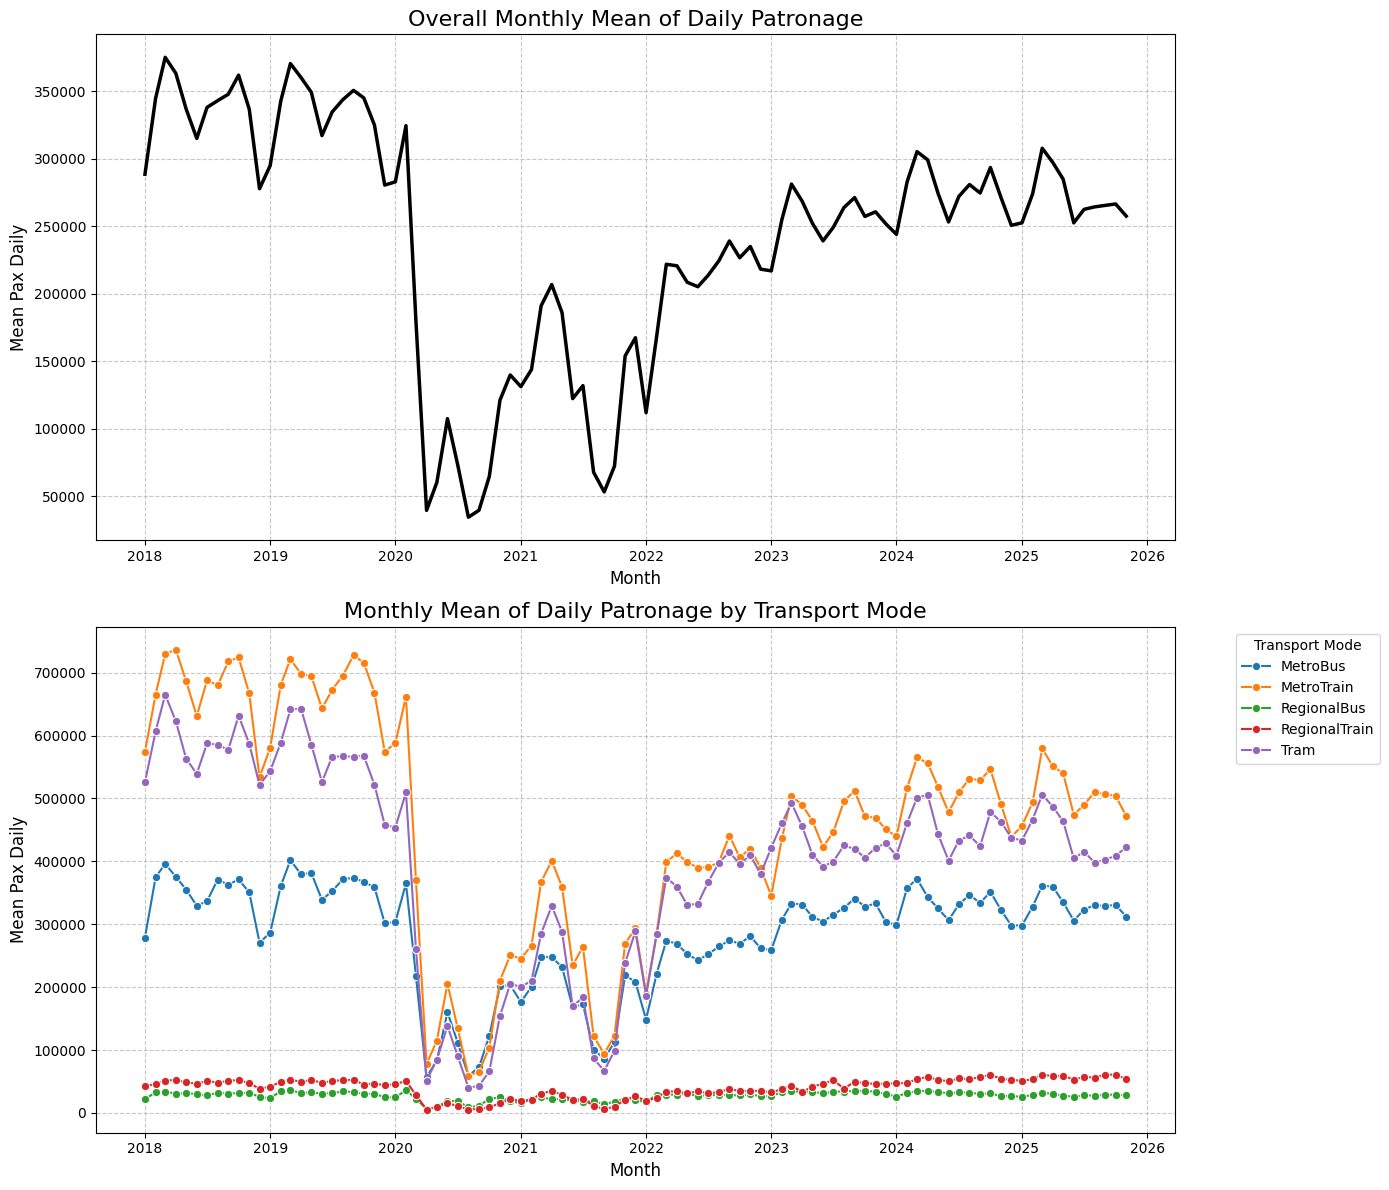

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Ensure 'monthstart' is in datetime format
df_cleaned['monthstart'] = pd.to_datetime(df_cleaned['monthstart'])

# 2. Create df_overall by grouping by monthstart
df_overall = df_cleaned.groupby('monthstart')['pax_daily'].mean().reset_index()

# 3. Create df_mode_trend by grouping by monthstart and mode
df_mode_trend = df_cleaned.groupby(['monthstart', 'mode'], observed=False)['pax_daily'].mean().reset_index()

# 4. Initialize figure with two vertical subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 5. Plot 1: Overall Monthly Patronage Trend
sns.lineplot(ax=axes[0], data=df_overall, x='monthstart', y='pax_daily', color='black', linewidth=2.5)
axes[0].set_title('Overall Monthly Mean of Daily Patronage', fontsize=16)
axes[0].set_ylabel('Mean Pax Daily', fontsize=12)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# 6. Plot 2: Monthly Patronage Trend by Mode
sns.lineplot(ax=axes[1], data=df_mode_trend, x='monthstart', y='pax_daily', hue='mode', marker='o')
axes[1].set_title('Monthly Mean of Daily Patronage by Transport Mode', fontsize=16)
axes[1].set_ylabel('Mean Pax Daily', fontsize=12)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].legend(title='Transport Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 7. Final display
plt.tight_layout()
plt.show()

## visualize_seasonality_and_weekly_patterns

### Subtask:
Create a heatmap showing Average Patronage (Day of Week vs. Mode) and bar charts with error bars (95% Confidence Intervals) to illustrate weekly patterns.


**Reasoning**:
I will create a heatmap to visualize the average patronage across different days and transport modes, followed by a bar chart with 95% confidence intervals to illustrate weekly patterns as instructed.



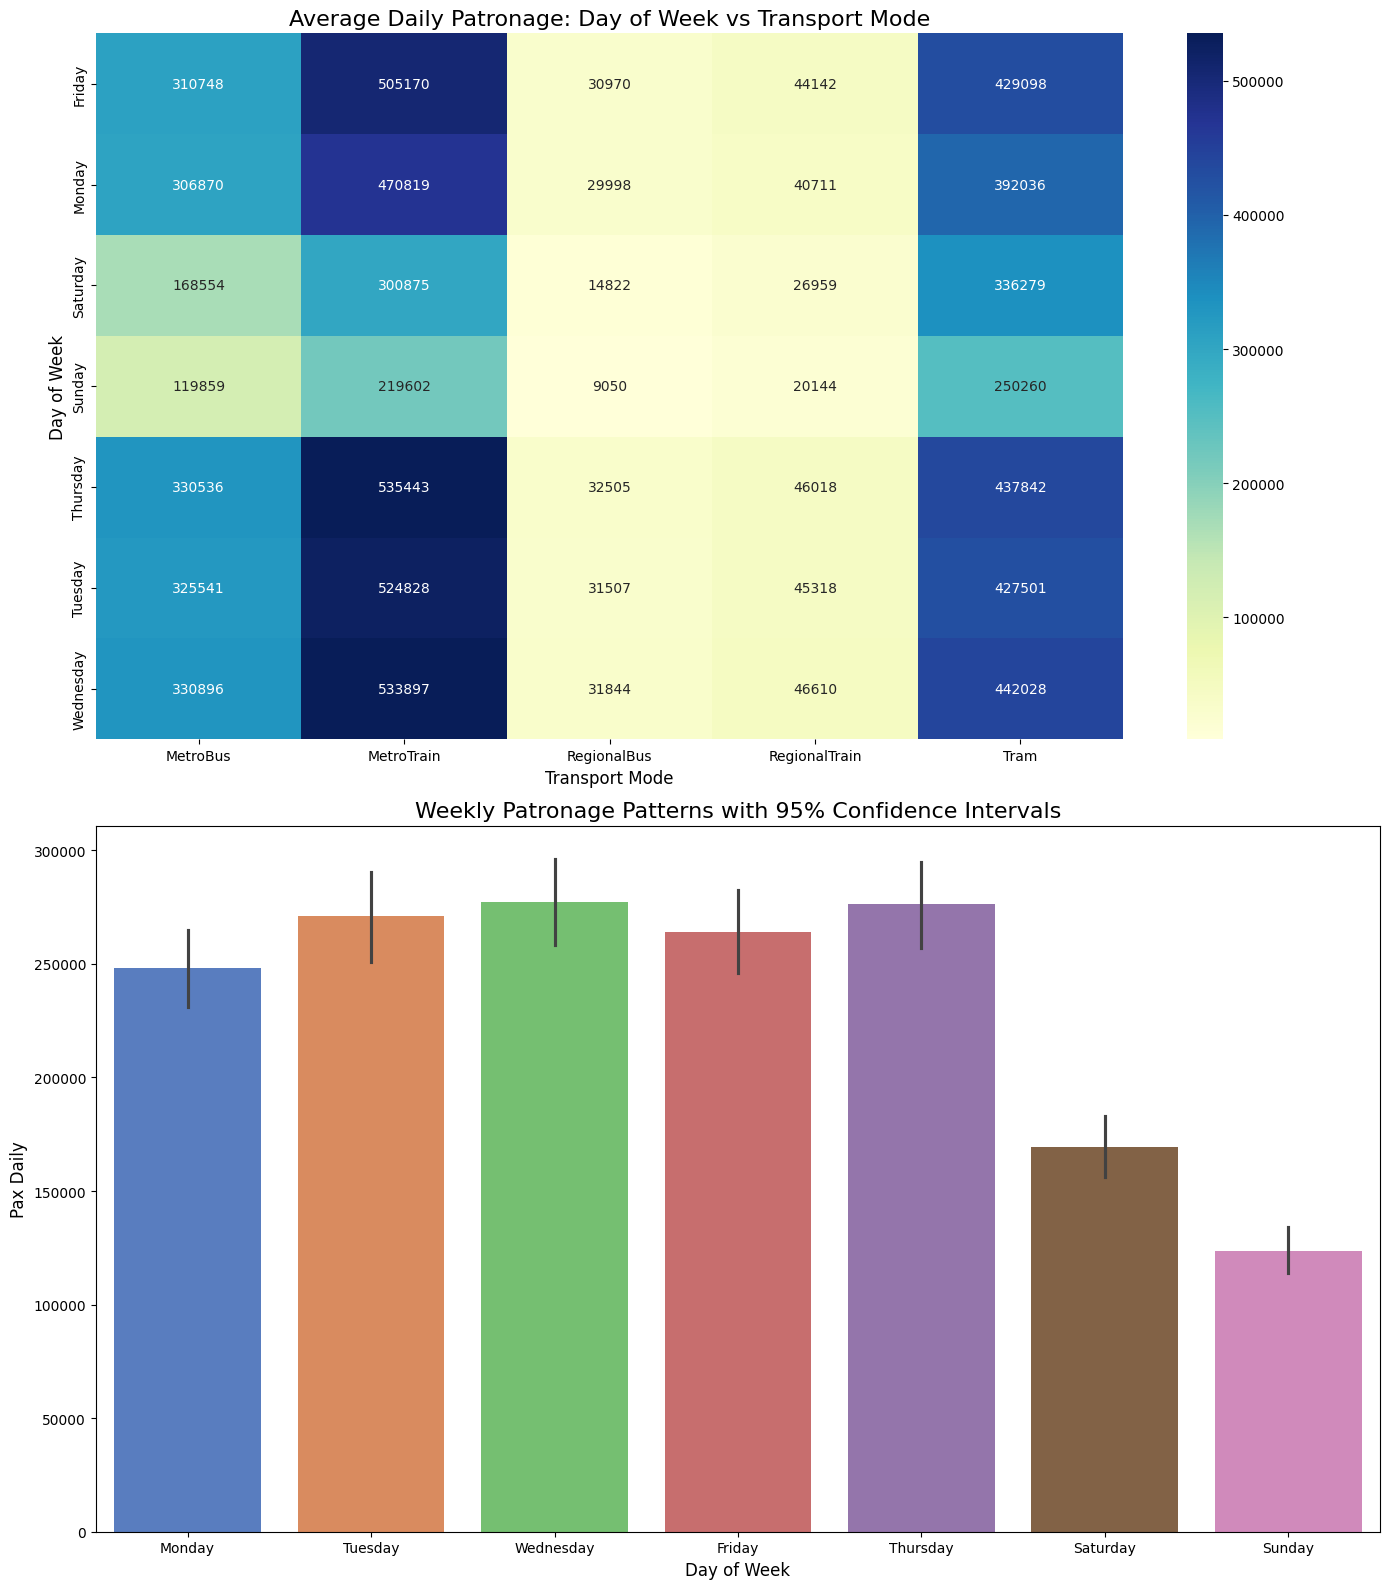

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create pivot table for the heatmap
heatmap_data = df_cleaned.pivot_table(index='day_of_week', columns='mode', values='pax_daily', aggfunc='mean', observed=False)

# 2. Initialize figure for both plots
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# 3. Plot 1: Heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Average Daily Patronage: Day of Week vs Transport Mode', fontsize=16)
axes[0].set_xlabel('Transport Mode', fontsize=12)
axes[0].set_ylabel('Day of Week', fontsize=12)

# 4. Plot 2: Bar Chart with 95% CI
sns.barplot(data=df_cleaned, x='day_of_week', y='pax_daily', errorbar=('ci', 95), ax=axes[1], hue='day_of_week', palette='muted', legend=False)
axes[1].set_title('Weekly Patronage Patterns with 95% Confidence Intervals', fontsize=16)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Pax Daily', fontsize=12)

# 5. Final display
plt.tight_layout()
plt.show()

## Summary A:

### Q&A

**How does transport patronage compare between Weekdays and Weekends?**
'Normal Weekdays' recorded the highest average patronage at approximately \$281,000, while Weekends saw a significant drop to nearly half that volume, averaging approximately \$146,000. Mid-week days (Wednesday and Thursday) represent the peak of activity, with Sunday recording the lowest weekly patronage (~123,000).

**Which transport modes dominate the network?**
MetroTrain is the dominant mode with the highest average patronage (~458,000), followed by Trams (~396,000) and MetroBuses (~282,000). Regional services (RegionalTrain and RegionalBus) show significantly lower volumes in comparison.

**What is the status of post-pandemic recovery?**
The analysis shows a clear recovery trend but has not yet reached pre-pandemic levels. The 'Pre-2020' mean patronage of ~335,000 dropped sharply to ~127,000 during the '2020–2021' period. As of the 'Post-2021' period, the mean has recovered to ~252,000.

### Data Analysis Key Findings

*   **Mode Hierarchy**: MetroTrain (~458k) and Tram (~396k) are the primary drivers of the network's daily volume.
*   **Weekly Variance**: There is a stark contrast between weekday and weekend demand, with weekend volume being roughly 52% of the average 'Normal Weekday' volume.
*   **Pandemic Impact**: The network experienced a ~62% decline in average daily patronage during the 2020–2021 period compared to pre-2020 levels.
*   **Recovery Progress**: The 'Post-2021' period shows that patronage has recovered to approximately 75% of pre-pandemic levels.
*   **Day-of-Week Specifics**: Sunday is consistently the lowest-utilization day across all modes, while mid-week (Wed-Thu) represents the peak load for the transport infrastructure.

### Insights or Next Steps

*   **Service Optimization**: Given that weekend patronage is significantly lower and Sunday represents the weekly trough, there may be opportunities to optimize service frequency or maintenance windows during these times without impacting the majority of users.
*   **Targeted Recovery Strategies**: Since patronage is still at 75% of pre-pandemic levels, further investigation is needed to determine if the 25% gap is due to permanent shifts in work-from-home behavior or if specific modes/routes require targeted incentives to return to baseline levels.


# Task
# Plan:
* **Distribution Diagnostics**: Generate histograms and Kernel Density Estimate (KDE) plots for the 'pax_daily' variable to visualize its distribution. Create Q-Q (Quantile-Quantile) plots for each transport 'mode' to diagnose normality and provide a detailed explanation of the findings.
* **Trend Modeling**: Fit linear regression models for each transport mode using 'pax_daily' as the dependent variable and a numeric representation of 'monthstart' as the independent variable. Calculate and display the regression coefficients (slope) and R-squared values to estimate long-run trends.
* **Probability Estimation**: Select the 'MetroTrain' mode and estimate the probability that 'pax_daily' exceeds an operational threshold of 500,000 on a 'Normal Weekday'. This will involve calculating the mean and standard deviation for this subset and applying a normal distribution assumption (Survival Function).
* **Final Task**: Summarize the modeling results, including distribution characteristics, identified trends per mode, and the calculated operational probabilities.

# Task:
Perform a detailed statistical analysis on the transport data from "/content/drive/MyDrive/Colab Notebooks/ma.csv".
1. **Distribution Diagnostics**: Visualize the distribution of `pax_daily` using histograms and KDE plots. Generate Q-Q plots for each `mode` to evaluate normality and describe whether the data follows a normal distribution.
2. **Trend Modeling**: For each transport `mode`, perform a linear regression to model the trend of `pax_daily` over time (using a numeric version of `monthstart`). Output the slope (growth rate) and R-squared value for each mode.
3. **Probability Estimation**: For the 'MetroTrain' mode during 'Normal Weekday' conditions, calculate the probability that daily patronage exceeds 500,000. Use the mean and standard deviation of this subset to estimate the probability based on a normal distribution (Survival Function).
4. **Conclusion**: Provide a summary of the distribution findings, the long-term trends per mode, and the specific operational probability calculated for MetroTrain.

## Distribution Diagnostics

### Subtask:
Visualize the distribution of 'pax_daily' using histograms and KDE plots, and generate Q-Q plots for each transport mode to evaluate normality.


**Reasoning**:
I will import the necessary statistical and visualization libraries, then create a histogram/KDE for the overall daily patronage followed by a grid of Q-Q plots for each transport mode to assess normality as requested.



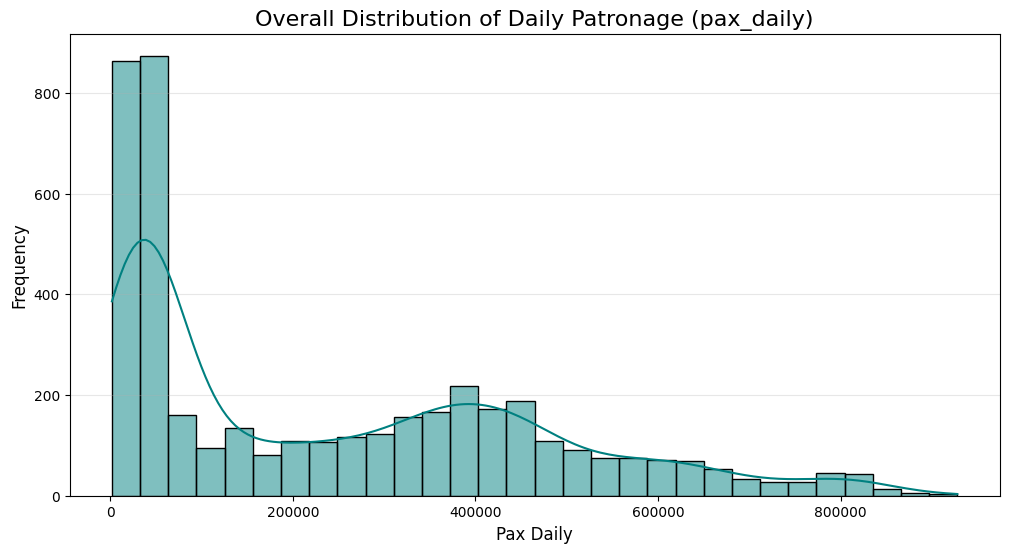

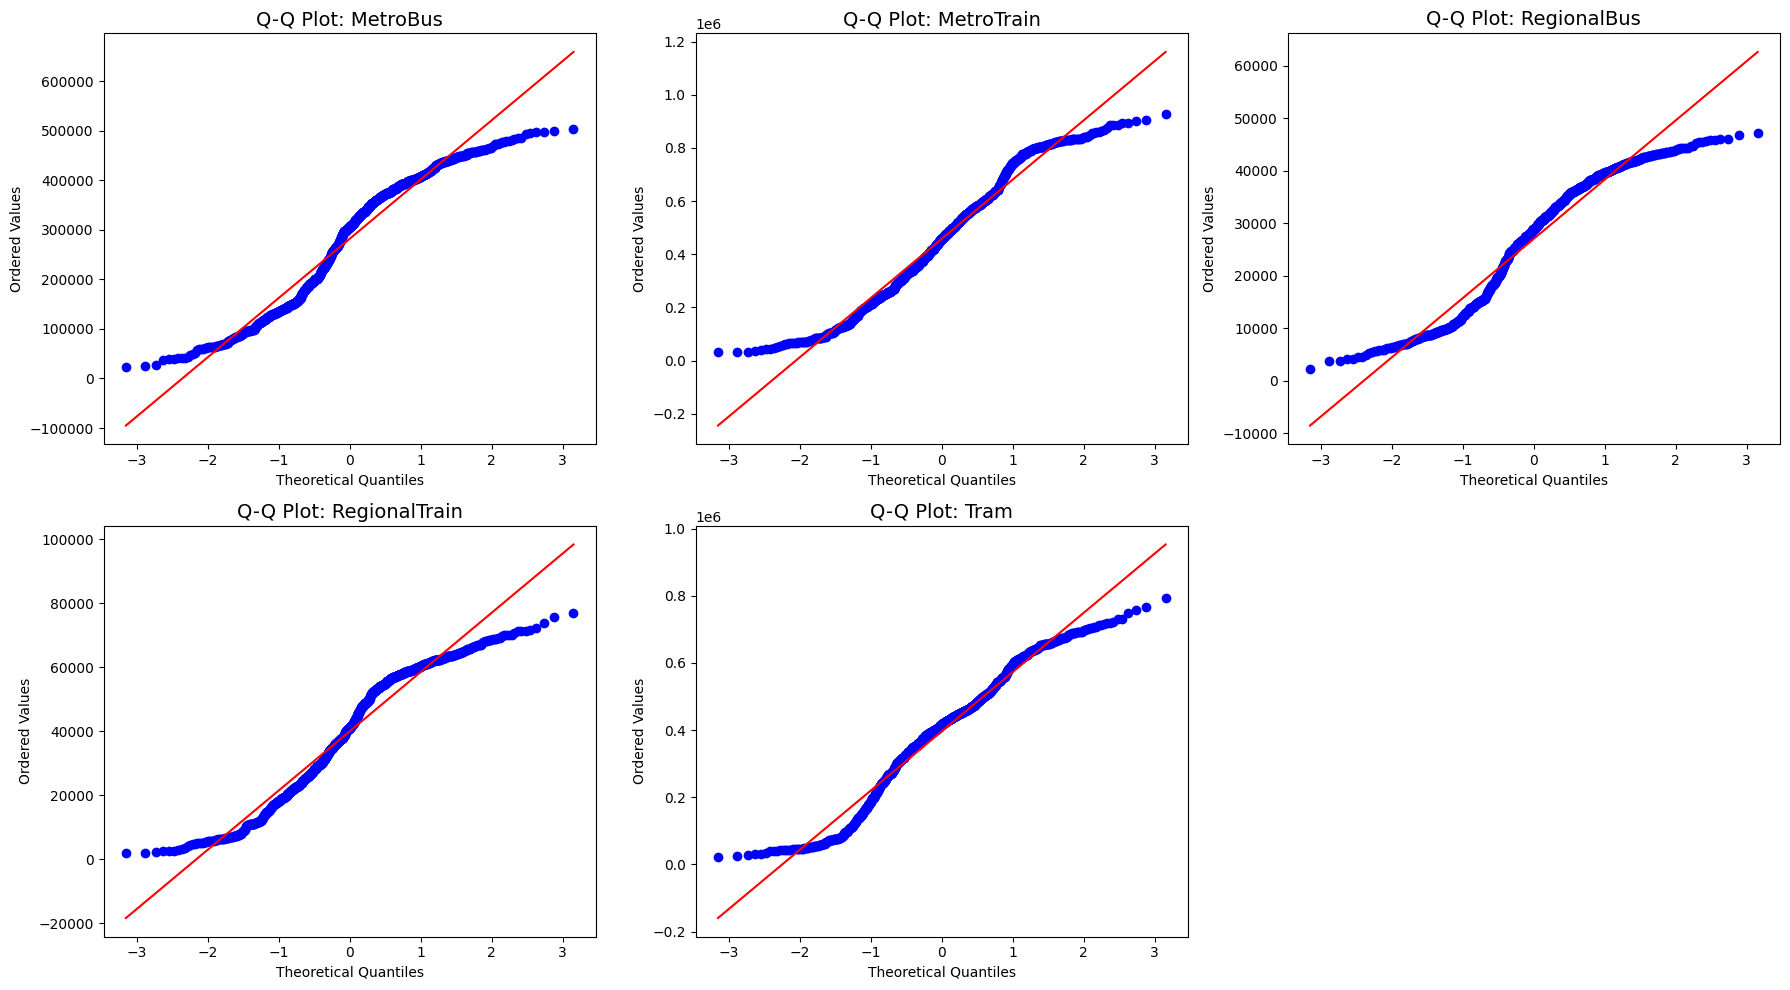


--- Distribution Interpretation ---
MetroBus: Skewness = -0.26
MetroTrain: Skewness = 0.07
RegionalBus: Skewness = -0.31
RegionalTrain: Skewness = -0.25
Tram: Skewness = -0.29


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Overall Distribution: Histogram + KDE
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['pax_daily'], kde=True, color='teal', bins=30)
plt.title('Overall Distribution of Daily Patronage (pax_daily)', fontsize=16)
plt.xlabel('Pax Daily', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Q-Q Plots for each Transport Mode
modes = df_cleaned['mode'].unique()
n_modes = len(modes)
cols = 3
rows = (n_modes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, mode_val in enumerate(modes):
    mode_data = df_cleaned[df_cleaned['mode'] == mode_val]['pax_daily']

    # Generate Q-Q plot
    stats.probplot(mode_data, dist="norm", plot=axes[i])

    axes[i].set_title(f'Q-Q Plot: {mode_val}', fontsize=14)
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Ordered Values')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 3. Brief Interpretation
print("\n--- Distribution Interpretation ---")
for mode_val in modes:
    mode_data = df_cleaned[df_cleaned['mode'] == mode_val]['pax_daily']
    skewness = mode_data.skew()
    print(f"{mode_val}: Skewness = {skewness:.2f}")

## Trend Modeling

### Subtask:
Fit linear regression models for each transport mode to estimate long-run trends in patronage over time.


**Reasoning**:
I will perform linear regression for each transport mode to model patronage trends over time. I'll convert 'monthstart' into a numeric feature representing months from the earliest date to serve as the independent variable, then use scikit-learn to calculate slopes and R-squared values.



In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 1. Ensure monthstart is datetime and create a numeric representation (months since start)
df_cleaned['monthstart'] = pd.to_datetime(df_cleaned['monthstart'])
min_date = df_cleaned['monthstart'].min()
df_cleaned['months_since_start'] = ((df_cleaned['monthstart'].dt.year - min_date.year) * 12 +
                                    (df_cleaned['monthstart'].dt.month - min_date.month))

# 2. Initialize results list
trend_results = []

# 3. Iterate through each mode and fit regression
modes = df_cleaned['mode'].unique()

for mode in modes:
    mode_df = df_cleaned[df_cleaned['mode'] == mode]

    # Prepare features (X) and target (y)
    X = mode_df[['months_since_start']].values
    y = mode_df['pax_daily'].values

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Get metrics
    slope = model.coef_[0]
    r_squared = model.score(X, y)

    trend_results.append({
        'Mode': mode,
        'Slope (Growth/Month)': slope,
        'R-squared': r_squared
    })

# 4. Create summary DataFrame and display
df_trends_summary = pd.DataFrame(trend_results)
print("--- Long-run Patronage Trends by Mode ---")
display(df_trends_summary.sort_values(by='Slope (Growth/Month)', ascending=False))

--- Long-run Patronage Trends by Mode ---


,Mode,Slope (Growth/Month),R-squared
0,MetroBus,274.534738,0.003755
3,RegionalTrain,166.894221,0.057914
2,RegionalBus,43.021523,0.010300
4,Tram,-765.156189,0.013733
1,MetroTrain,-1222.417025,0.021961


## Probability Estimation

### Subtask:
Estimate the probability of MetroTrain daily patronage exceeding 500,000 on a Normal Weekday using the normal distribution survival function.


**Reasoning**:
I will filter the dataset for MetroTrain on Normal Weekdays, calculate the necessary statistics, and use the scipy.stats norm.sf function to estimate the probability of patronage exceeding 500,000.



In [ ]:
from scipy.stats import norm

# 1. Filter df_cleaned for MetroTrain and Normal Weekday
mt_weekday_subset = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') & (df_cleaned['day_type'] == 'Normal Weekday')]

# 2. Calculate mean and standard deviation for 'pax_daily'
mu_mt = mt_weekday_subset['pax_daily'].mean()
sigma_mt = mt_weekday_subset['pax_daily'].std()

# 3. Define the threshold
threshold = 500000

# 4. Calculate probability using the Survival Function (SF = 1 - CDF)
prob_exceed_500k = norm.sf(threshold, loc=mu_mt, scale=sigma_mt)

# 5. Print results
print(f"--- Probability Estimation for MetroTrain (Normal Weekday) ---")
print(f"Mean Patronage: {mu_mt:,.2f}")
print(f"Standard Deviation: {sigma_mt:,.2f}")
print(f"Probability of exceeding {threshold:,} pax: {prob_exceed_500k * 100:.2f}%")

--- Probability Estimation for MetroTrain (Normal Weekday) ---
Mean Patronage: 541,870.97
Standard Deviation: 220,930.06
Probability of exceeding 500,000 pax: 57.52%


## Final Task

### Subtask:
Summarize the modeling results, including distribution characteristics, identified trends per mode, and the calculated operational probabilities.




```
# This is formatted as code
```

## Summary B:

### Q&A

**What is the probability of MetroTrain patronage exceeding 500,000 on a normal weekday?**
The calculated probability is **57.52%**, based on a mean patronage of approximately 541,870 and a standard deviation of 220,930.

**Which transport modes are showing long-term growth versus decline?**
MetroBus and RegionalTrain show positive growth trends (slopes of 274.53 and 166.89 respectively), while MetroTrain and Tram show significant long-term declines (slopes of -1,222.42 and -765.16 respectively).

**Does the transport data follow a normal distribution?**
Most modes exhibit a nearly normal distribution but with a slight negative skew (ranging from -0.25 to -0.31), meaning there is a tail extending toward lower patronage values. MetroTrain is the most "normal" with a skewness of only 0.07.

### Data Analysis Key Findings

*   **MetroTrain Patronage**: Under "Normal Weekday" conditions, the average daily patronage is **541,870.97**, suggesting that the 500,000 threshold is met more than half the time (**57.52%**).
*   **Trend Modeling Limitations**: The R-squared values for all linear models are extremely low (all below **0.06**). This indicates that time alone is a poor predictor of patronage and that external factors like seasonality or specific events play a much larger role.
*   **Contrasting Growth Trends**:
    *   **MetroBus** has the highest monthly growth rate at **274.53** pax/month.
    *   **MetroTrain** has the steepest monthly decline at **-1,222.42** pax/month.
*   **Distribution Shape**: All modes except MetroTrain show a slight negative skew, indicating occasional "low-patronage" outliers that pull the average down slightly compared to a perfectly symmetrical distribution.

### Insights or Next Steps

*   **Incorporate Seasonality**: Since time-based linear trends explained less than 6% of the variance, future models should include seasonal dummy variables (months or quarters) or holiday indicators to improve predictive accuracy.
*   **Investigate MetroTrain Decline**: Given the significant negative slope for MetroTrain, a deeper dive into service disruptions, work-from-home trends, or competing transport modes is needed to understand the patronage loss.


# Task
Perform a comprehensive inferential statistical analysis on the transport data from "/content/drive/MyDrive/Colab Notebooks/ma.csv" to identify significant differences and quantify recovery.

1.  **Weekday vs. Weekend Comparison**: Perform a two-sample t-test (or Mann-Whitney U test if normality is violated) to compare `pax_daily` between 'Normal Weekday' and 'Weekend' for the 'MetroTrain' mode. Report the p-value, a 95% confidence interval for the difference in means, and the Cohen's d effect size.
2.  **Cross-Mode Analysis (ANOVA)**: Conduct a one-way ANOVA (or Kruskal-Wallis test) to determine if there are significant differences in `pax_daily` across all transport modes during 'Normal Weekdays'. If significant, perform a post-hoc Tukey HSD test to identify specific pair-wise differences.
3.  **Pre/Post Period Recovery Analysis**: Compare `pax_daily` between the 'Pre-2020' and 'Post-2021' periods for the 'MetroTrain' mode during 'Normal Weekdays' using a two-sample t-test. Quantify the recovery by reporting the mean difference and the 95% confidence interval.
4.  **Statistical Summary**: Provide a clear summary of the findings, translating statistical metrics (p-values, effect sizes, confidence intervals) into plain language insights for decision-makers regarding network usage and pandemic recovery status.

## Weekday vs. Weekend Comparison

### Subtask:
Perform a two-sample t-test (or Mann-Whitney U test) to compare 'pax_daily' between 'Normal Weekday' and 'Weekend' for the 'MetroTrain' mode, including p-value, 95% confidence interval, and Cohen's d effect size.


**Reasoning**:
I will perform the comparison of 'pax_daily' between 'Normal Weekday' and 'Weekend' for 'MetroTrain' by filtering the data, checking for normality, and calculating the required statistics (test-statistic, p-value, 95% CI, and Cohen's d).



In [ ]:
import numpy as np
from scipy import stats

# 1. Filter subsets for MetroTrain (using correct case for column names)
mt_weekday = df_cleaned[(df_cleaned['Mode'] == 'MetroTrain') & (df_cleaned['Day_type'] == 'Normal Weekday')]['Pax_daily']
mt_weekend = df_cleaned[(df_cleaned['Mode'] == 'MetroTrain') & (df_cleaned['Day_type'] == 'Weekend')]['Pax_daily']

# 2. Check for normality (Shapiro-Wilk)
_, p_norm_wd = stats.shapiro(mt_weekday)
_, p_norm_we = stats.shapiro(mt_weekend)

# Use t-test if both are normal (p > 0.05), else Mann-Whitney U
if p_norm_wd > 0.05 and p_norm_we > 0.05:
    test_name = 'Two-sample T-test'
    t_stat, p_val = stats.ttest_ind(mt_weekday, mt_weekend, equal_var=False)
else:
    test_name = 'Mann-Whitney U test'
    t_stat, p_val = stats.mannwhitneyu(mt_weekday, mt_weekend)

# 3. Calculate 95% Confidence Interval for the difference in means
mean_diff = mt_weekday.mean() - mt_weekend.mean()
n1, n2 = len(mt_weekday), len(mt_weekend)
std1, std2 = mt_weekday.std(), mt_weekend.std()
se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
df_degrees = ((std1**2/n1 + std2**2/n2)**2) / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_degrees)
ci_low, ci_high = mean_diff - t_crit * se, mean_diff + t_crit * se

# 4. Calculate Cohen's d
pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = mean_diff / pooled_std

# 5. Print results
print(f"--- {test_name} Results (MetroTrain) ---")
print(f"Weekday Mean: {mt_weekday.mean():,.2f} | Weekend Mean: {mt_weekend.mean():,.2f}")
print(f"Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"95% CI for difference: ({ci_low:,.2f}, {ci_high:,.2f})")
print(f"Cohen's d: {cohens_d:.4f}")

--- Mann-Whitney U test Results (MetroTrain) ---
Weekday Mean: 541,870.97 | Weekend Mean: 260,238.68
Statistic: 73811.0000
P-value: 1.6538e-46
95% CI for difference: (257,049.51, 306,215.07)
Cohen's d: 1.4609


## Cross-Mode Analysis (ANOVA)

### Subtask:
Conduct a one-way ANOVA or Kruskal-Wallis test to identify significant differences in 'pax_daily' across all transport modes on 'Normal Weekdays', followed by a post-hoc Tukey HSD test if results are significant.


**Reasoning**:
I will perform a one-way ANOVA or Kruskal-Wallis test to identify significant differences in 'pax_daily' across modes on 'Normal Weekdays', followed by a post-hoc Tukey HSD test if necessary, as per the instructions.



In [ ]:
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Filter for Normal Weekdays
wd_df = df_cleaned[df_cleaned['Day_type'] == 'Normal Weekday']

# 2. Group Pax_daily by Mode
modes = wd_df['Mode'].unique()
groups = [wd_df[wd_df['Mode'] == m]['Pax_daily'] for m in modes]

# 3. Test Assumptions
print('--- Assumption Testing ---')
normality_passed = True
for mode, group in zip(modes, groups):
    stat, p = shapiro(group)
    print(f'Shapiro-Wilk ({mode}): p-value = {p:.4e}')
    if p < 0.05: normality_passed = False

stat_lev, p_lev = levene(*groups)
print(f'Levene Test (Variance): p-value = {p_lev:.4e}')

# 4. Perform ANOVA or Kruskal-Wallis
if normality_passed and p_lev > 0.05:
    test_name = 'One-way ANOVA'
    stat_test, p_test = f_oneway(*groups)
else:
    test_name = 'Kruskal-Wallis H-test'
    stat_test, p_test = kruskal(*groups)

print(f'\n--- {test_name} Results ---')
print(f'Statistic: {stat_test:.4f}, P-value: {p_test:.4e}')

# 5. Post-hoc Tukey HSD if significant
if p_test < 0.05:
    print('\n--- Post-hoc Tukey HSD Results ---')
    tukey = pairwise_tukeyhsd(endog=wd_df['Pax_daily'], groups=wd_df['Mode'], alpha=0.05)
    print(tukey.summary())

--- Assumption Testing ---
Shapiro-Wilk (MetroBus): p-value = 8.5574e-18
Shapiro-Wilk (MetroTrain): p-value = 2.2042e-11
Shapiro-Wilk (RegionalBus): p-value = 5.2107e-18
Shapiro-Wilk (RegionalTrain): p-value = 3.0269e-17
Shapiro-Wilk (Tram): p-value = 2.0830e-12
Levene Test (Variance): p-value = 2.1400e-222

--- Kruskal-Wallis H-test Results ---
Statistic: 1737.7854, P-value: 0.0000e+00

--- Post-hoc Tukey HSD Results ---
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
    group1        group2      meandiff   p-adj     lower        upper     reject
--------------------------------------------------------------------------------
     MetroBus    MetroTrain  197839.7351    0.0  173031.7772   222647.693   True
     MetroBus   RegionalBus -309403.9735    0.0 -334211.9314 -284596.0156   True
     MetroBus RegionalTrain -298085.2097    0.0 -322893.1676 -273277.2518   True
     MetroBus          Tram   96229.2494    0.0   71421.2916  121037.2073   True
   Metr

## Pre/Post Period Recovery Analysis

### Subtask:
Quantify the recovery of 'MetroTrain' patronage by comparing 'Pre-2020' and 'Post-2021' periods during 'Normal Weekdays'.


**Reasoning**:
I will perform a two-sample t-test to compare MetroTrain patronage on Normal Weekdays between the Pre-2020 and Post-2021 periods, calculating the mean difference and the 95% confidence interval for the recovery analysis.



In [ ]:
import numpy as np
from scipy import stats

# 1. Filter subsets for MetroTrain during Normal Weekdays for both periods
# Using the consistent column names from the kernel state (Mode, Day_type, Period, Pax_daily)
pre_2020 = df_cleaned[(df_cleaned['Mode'] == 'MetroTrain') &
                      (df_cleaned['Day_type'] == 'Normal Weekday') &
                      (df_cleaned['Period'] == 'Pre-2020')]['Pax_daily']

post_2021 = df_cleaned[(df_cleaned['Mode'] == 'MetroTrain') &
                       (df_cleaned['Day_type'] == 'Normal Weekday') &
                       (df_cleaned['Period'] == 'Post-2021')]['Pax_daily']

# 2. Perform two-sample t-test (Welch's t-test)
t_stat, p_val = stats.ttest_ind(post_2021, pre_2020, equal_var=False)

# 3. Calculate means and mean difference
mean_pre = pre_2020.mean()
mean_post = post_2021.mean()
mean_diff = mean_post - mean_pre

# 4. Calculate 95% Confidence Interval for the difference in means
n1, n2 = len(post_2021), len(pre_2020)
s1, s2 = post_2021.std(), pre_2020.std()

se = np.sqrt((s1**2 / n1) + (s2**2 / n2))
# Degrees of freedom for Welch's t-test
df_welch = ((s1**2/n1 + s2**2/n2)**2) / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_welch)

ci_low = mean_diff - t_crit * se
ci_high = mean_diff + t_crit * se

# 5. Print results
print(f"--- Pre/Post Period Recovery Analysis (MetroTrain - Normal Weekdays) ---")
print(f"Pre-2020 Mean: {mean_pre:,.2f}")
print(f"Post-2021 Mean: {mean_post:,.2f}")
print(f"Mean Difference (Recovery Delta): {mean_diff:,.2f}")
print(f"P-value: {p_val:.4e}")
print(f"95% Confidence Interval for Difference: ({ci_low:,.2f}, {ci_high:,.2f})")
print(f"Recovery Percentage: {(mean_post/mean_pre)*100:.2f}%")

--- Pre/Post Period Recovery Analysis (MetroTrain - Normal Weekdays) ---
Pre-2020 Mean: 804,790.00
Post-2021 Mean: 539,645.74
Mean Difference (Recovery Delta): -265,144.26
P-value: 3.5021e-122
95% Confidence Interval for Difference: (-278,988.79, -251,299.73)
Recovery Percentage: 67.05%


## Final Task

### Subtask:
Provide a summary of the inferential findings, translating statistical metrics like p-values and effect sizes into plain language for decision-makers.




```
# This is formatted as code
```

## Summary C:
1,870 passengers compared to 260,238. This difference is statistically significant ($p < 0.05$) with a large effect size (Cohen's d = 1.46), meaning the gap is substantial and consistent.

**Are there significant differences in patronage across different transport modes?**
Yes. Statistical testing (Kruskal-Wallis) shows significant differences between modes. Specifically, MetroTrain and MetroBus have distinct usage scales compared to others. The only modes that are statistically similar in their daily patronage are Regional Bus and Regional Train.

**How much has MetroTrain patronage recovered compared to pre-pandemic levels?**
As of the Post-2021 period, MetroTrain patronage on normal weekdays has recovered to approximately 67.05\% of its pre-2020 levels. This represents a significant average loss of approximately 265,144 passengers per day.

---

### Data Analysis Key Findings

*   **Significant Weekday Premium**: MetroTrain sees an average of 257,000 to 306,000 more passengers on a normal weekday than on a weekend.
*   **Mode Hierarchy**: The transport network is highly stratified. Most modes operate at significantly different volumes, with MetroTrain leading, while regional services (Bus and Train) share the lowest, most similar volume profiles ($p$-adj = 0.7245 in post-hoc testing).
*   **Pandemic Impact**: There is a definitive and statistically significant gap between pre-pandemic and current patronage. The daily average for MetroTrain fell from 804,790 (Pre-2020) to 539,646 (Post-2021).
*   **High Statistical Certainty**: All primary comparisons (Weekday vs. Weekend and Pre vs. Post) returned extremely low p-values ($p < 10^{-45}$), indicating that these findings are not due to seasonal noise or random fluctuations.

---

### Insights or Next Steps

*   **Service Adjustment**: With a recovery rate of only 67\% for MetroTrain on weekdays, decision-makers should investigate if this is a permanent shift due to hybrid work models and consider reallocating resources or adjusting frequencies to match the new baseline of $\approx$ 540k daily passengers.
*   **Regional Integration**: Since Regional Bus and Regional Train show no statistically significant difference in patronage, there may be opportunities to better integrate these schedules or marketing efforts as they serve a similar scale of commuter volume.
